# Введение в библиотеки обработки финансовых данных
Демо‑ноутбук для открытого урока по курсу **ML для финансового анализа**.

В ноутбуке:
- Загрузка данных с разных источников (yfinance, pandas-datareader, investpy, MOEX, Тинькофф)
- Базовая обработка в pandas и визуализация в matplotlib
- Специальная обработка: свечные графики и технические индикаторы

## 0. Установка необходимых библиотек (при необходимости)
Запустите этот блок, если какие-то из библиотек ещё не установлены.

## 1. Загрузка данных

### 1.1 Загрузка данных с помощью `yfinance`
Загрузка дневных котировок по тикеру (пример — Apple, AAPL).

In [6]:
import yfinance as yf
import pandas as pd

ticker = "AAPL"  # можно заменить на любой тикер, доступный в Yahoo Finance
df_yf = yf.download(ticker, period="1y", interval="1d")
df_yf.head()    #type: ignore

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-04,241.915878,243.010932,240.163808,241.776509,44383900
2024-12-05,241.945724,243.438971,241.039833,242.891459,40033900
2024-12-06,241.746628,243.528577,240.990055,241.816320,36870600
2024-12-09,245.639023,246.126822,240.661535,240.741177,44649200
2024-12-10,246.654449,247.092471,244.235382,245.778407,36914800


### 1.2 `pandas-datareader` — макро‑данные (пример FRED)
Пример: загрузка индекса S&P 500 или макроэкономического индикатора из FRED.

In [2]:
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime.now() - dt.timedelta(days=365)
end = dt.datetime.now()

# Пример: индекс S&P 500 с FRED (тикер '^GSPC' в Yahoo, но в FRED другие коды)
# Здесь для демонстрации используем индекс промышленного производства (INDPRO)
df_fred = web.DataReader('INDPRO', 'fred', start, end)
df_fred.tail()

,INDPRO
DATE,
2025-05-01,100.9773
2025-06-01,101.4280
2025-07-01,101.5910
2025-08-01,101.3300
2025-09-01,101.4279


### 1.3 `investpy` — международные рынки
Пример: исторические данные по акции с европейского рынка.

> Важно: API investpy периодически меняется. Этот пример носит демонстрационный характер.

In [3]:
import investpy

# Пример: берем акцию Banco Santander (Испания) для демонстрации
df_inv = investpy.get_stock_historical_data(
    stock='SAN',
    country='spain',
    from_date='01/01/2024',
    to_date='01/12/2024'
)
df_inv.head()   #type: ignore

ConnectionError: ERR#0015: error 403, try again later.

### 1.4 MOEX (Московская биржа) через ISS API
Самый универсальный способ — использовать HTTP API MOEX и загружать данные в pandas.

In [4]:
import requests

moex_url = (
    "https://iss.moex.com/iss/history/engines/stock/markets/shares/"
    "boards/TQBR/securities/SBER.json?from=2024-01-01&till=2024-12-01"
)
response = requests.get(moex_url)
data = response.json()

# Таблица с данными находится в разделе 'history'
columns = data['history']['columns']
rows = data['history']['data']
df_moex = pd.DataFrame(rows, columns=columns)

# Оставим основные колонки и приведём дату к datetime
df_moex['TRADEDATE'] = pd.to_datetime(df_moex['TRADEDATE'])
df_moex = df_moex[['TRADEDATE', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']]
df_moex.head()

,TRADEDATE,OPEN,HIGH,LOW,CLOSE,VOLUME
0,2024-01-03,271.90,274.70,271.00,274.56,20586020
1,2024-01-04,274.67,275.48,273.70,274.12,11729380
2,2024-01-05,274.30,274.69,272.80,273.62,9635550
3,2024-01-08,273.60,277.00,273.53,276.76,21489440
4,2024-01-09,276.97,278.00,274.71,275.28,20316030


### 1.5 Тинькофф Инвестиции
Для доступа нужен **API‑токен**. Ниже — минимальный пример структуры кода.


In [ ]:
from tinkoff.invest import Client, CandleInterval
from tinkoff.invest.utils import now
import os
import datetime as dt

In [5]:
TOKEN = str(os.getenv("T_SANDBOX_TOKEN"))  # не храните реальные токены в открытом виде
figi = "BBG004730N88"  # пример: SBER (нужно проверить актуальный FIGI)

# Пример шаблона, без реального запуска (чтобы не падать без токена)
if True:
    with Client(TOKEN) as client:
        candles = client.market_data.get_candles(
            figi=figi,
            from_=now() - dt.timedelta(days=7),
            to=now(),
            interval=CandleInterval.CANDLE_INTERVAL_DAY,
        )
        # Преобразование в DataFrame оставлено как упражнение


In [6]:
candles

GetCandlesResponse(candles=[HistoricCandle(open=Quotation(units=306, nano=480000000), high=Quotation(units=306, nano=870000000), low=Quotation(units=304, nano=0), close=Quotation(units=304, nano=960000000), volume=12942518, time=datetime.datetime(2025, 11, 26, 0, 0, tzinfo=datetime.timezone.utc), is_complete=True, candle_source=<CandleSource.CANDLE_SOURCE_EXCHANGE: 1>), HistoricCandle(open=Quotation(units=305, nano=470000000), high=Quotation(units=306, nano=250000000), low=Quotation(units=297, nano=330000000), close=Quotation(units=299, nano=530000000), volume=34517910, time=datetime.datetime(2025, 11, 27, 0, 0, tzinfo=datetime.timezone.utc), is_complete=True, candle_source=<CandleSource.CANDLE_SOURCE_EXCHANGE: 1>), HistoricCandle(open=Quotation(units=300, nano=860000000), high=Quotation(units=305, nano=260000000), low=Quotation(units=299, nano=50000000), close=Quotation(units=304, nano=170000000), volume=24863407, time=datetime.datetime(2025, 11, 28, 0, 0, tzinfo=datetime.timezone.utc

In [7]:
def tinkoff_candles_to_dataframe(candles):
    """
    Преобразует список свечей из Tinkoff Invest API в pandas DataFrame.
    
    Parameters:
    -----------
    candles : list or GetCandlesResponse
        Список свечей из client.market_data.get_candles()
    
    Returns:
    --------
    pd.DataFrame
        DataFrame с колонками: time, open, high, low, close, volume
    """
    data = []
    
    # Если это ответ от API, извлекаем список свечей
    if hasattr(candles, 'candles'):
        candles = candles.candles
    
    for candle in candles:
        data.append({
            'time': candle.time,
            'open': _quotation_to_float(candle.open),
            'high': _quotation_to_float(candle.high),
            'low': _quotation_to_float(candle.low),
            'close': _quotation_to_float(candle.close),
            'volume': candle.volume,
        })
    
    df = pd.DataFrame(data)
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    
    return df


def _quotation_to_float(quotation):
    """
    Преобразует Quotation объект из Tinkoff API в float.
    
    Quotation содержит units (целая часть) и nano (дробная часть в наносекундах).
    """
    return float(quotation.units) + float(quotation.nano) / 1e9

In [10]:
df_tinkoff = tinkoff_candles_to_dataframe(candles)
df_tinkoff.head()

,open,high,low,close,volume
time,,,,,
2025-11-26 00:00:00+00:00,306.48,306.87,304.00,304.96,12942518
2025-11-27 00:00:00+00:00,305.47,306.25,297.33,299.53,34517910
2025-11-28 00:00:00+00:00,300.86,305.26,299.05,304.17,24863407
2025-11-29 00:00:00+00:00,304.32,304.97,303.76,303.88,967797
2025-11-30 00:00:00+00:00,303.86,305.43,303.60,305.23,1979918


### 1.6 ByBit

In [1]:
from pybit.unified_trading import HTTP

In [2]:
# Создаем клиент для работы с Bybit (публичное API, токен не нужен)
session = HTTP(testnet=False)

In [3]:
# Параметры запроса
symbol = "BTCUSDT"
interval = "60"  # D = daily, 60 = 1 hour, 15 = 15 min, 1 = 1 min
limit = 200  # максимум 200 свечей за запрос

In [4]:
# Получаем исторические данные (klines/свечи)
response = session.get_kline(
    category="linear",  # "linear" для perpetual фьючерсов, "spot" для спотового рынка
    symbol=symbol,
    interval=interval,
    limit=limit
)

In [7]:
# Извлекаем данные
klines = response['result']['list']

# Преобразуем в DataFrame
df_bybit = pd.DataFrame(klines, columns=[
    'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
])

# Конвертируем типы данных
df_bybit['timestamp'] = pd.to_datetime(df_bybit['timestamp'].astype(int), unit='ms')
df_bybit['open'] = df_bybit['open'].astype(float)
df_bybit['high'] = df_bybit['high'].astype(float)
df_bybit['low'] = df_bybit['low'].astype(float)
df_bybit['close'] = df_bybit['close'].astype(float)
df_bybit['volume'] = df_bybit['volume'].astype(float)
df_bybit['turnover'] = df_bybit['turnover'].astype(float)

# Устанавливаем timestamp как индекс
df_bybit.set_index('timestamp', inplace=True)

# Сортируем по времени (Bybit возвращает в обратном порядке)
df_bybit = df_bybit.sort_index()

df_bybit.head()

,open,high,low,close,volume,turnover
timestamp,,,,,,
2025-11-26 05:00:00,87177.4,87698.0,87160.3,87470.7,2144.966,1.876348e+08
2025-11-26 06:00:00,87470.7,87844.0,87400.0,87753.7,1872.562,1.640710e+08
2025-11-26 07:00:00,87753.7,87943.5,87650.2,87900.0,1498.865,1.315592e+08
2025-11-26 08:00:00,87900.0,87911.4,87369.2,87388.1,1826.311,1.599214e+08
2025-11-26 09:00:00,87388.1,87411.0,86700.0,86787.7,3170.536,2.759491e+08


## 2. Базовая обработка данных
Используем `pandas` и `matplotlib` на примере данных из `yfinance`.

In [ ]:
import matplotlib.pyplot as plt

# Проверка структуры данных
df = df_yf.copy()   #type: ignore
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2024-12-03 to 2025-12-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB
None
Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL          AAPL
count   251.000000  251.000000  251.000000  251.000000  2.510000e+02
mean    229.863324  232.299359  227.205982  229.535723  5.442933e+07
std      24.195955   23.889464   24.318585   24.065444  2.322021e+07
min     171.832397  189.691325  168.633346  171.364011  1.236362e+07
25%     209.573761  211.600520  207.471744  209.573763  4.102490e+07
50%     229.807220  232

### 2.1 Очистка и простые трансформации

In [7]:
# Удалим пропуски и добавим дневную доходность
df = df.dropna().copy()
df['return'] = df['Close'].pct_change()
df[['Close', 'return']].head()

Price,Close,return
Ticker,AAPL,
Date,,
2024-12-03,241.557495,NaN
2024-12-04,241.915878,0.001484
2024-12-05,241.945740,0.000123
2024-12-06,241.746643,-0.000823
2024-12-09,245.639023,0.016101


### 2.2 Простая визуализация цен и доходности

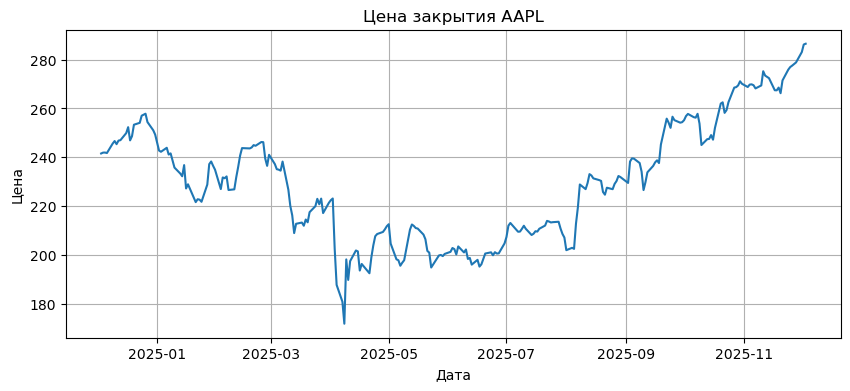

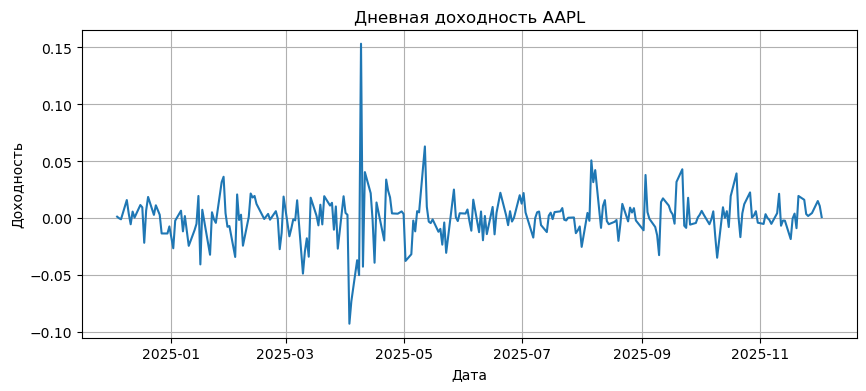

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Close'])
plt.title(f'Цена закрытия {ticker}')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df.index, df['return'])
plt.title(f'Дневная доходность {ticker}')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.grid(True)
plt.show()

## 3. Специальная обработка
Свечные графики и технические индикаторы.

### 3.1 Свечные графики с помощью `mplfinance`
Быстрый способ построить классический OHLC/свечной график.

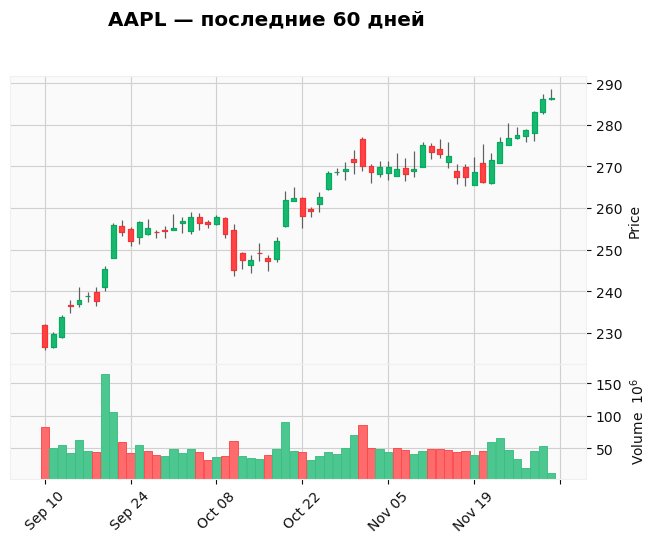

In [17]:
import mplfinance as mpf

# Для mplfinance нужен индекс‑дата и столбцы 'Open','High','Low','Close','Volume'
df_mpf = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df_mpf.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
mpf.plot(df_mpf.tail(60), type='candle', volume=True, style='yahoo', title=f'{ticker} — последние 60 дней')

### 3.2 Технические индикаторы: `TA-Lib`
`TA-Lib` — классическая библиотека теханализа, но требует системной установки.
Блок можно оставить закомментированным и использовать как демонстрацию.

In [ ]:
import talib

In [ ]:
df['RSI_14'] = talib.RSI(df['Close'].values.flatten(), timeperiod=14)   #type: ignore
df['SMA_20'] = talib.SMA(df['Close'].values.flatten(), timeperiod=20)   #type: ignore
df[['Close', 'RSI_14', 'SMA_20']].tail()

Price,Close,RSI_14,SMA_20
Ticker,AAPL,,
Date,,,
2025-11-26,277.549988,66.952271,271.128015
2025-11-28,278.850006,68.407589,271.513658
2025-12-01,283.100006,72.648182,272.163251
2025-12-02,286.190002,75.249435,273.033279
2025-12-03,286.519989,75.517217,273.870355


### 3.3 `pandas_ta` — индикаторы прямо в pandas
Не требует системной установки C‑библиотек, удобно для демо.

In [ ]:
import pandas_ta as pta

In [ ]:
df['RSI_14'] = pta.rsi(df[('Close', 'AAPL')], length=14)
df['SMA_20'] = pta.sma(df[('Close', 'AAPL')], length=20)
df[['Close', 'SMA_20', 'RSI_14']].tail()

Price,Close,SMA_20,RSI_14
Ticker,AAPL,,
Date,,,
2025-11-26,277.549988,271.128015,66.952271
2025-11-28,278.850006,271.513658,68.407589
2025-12-01,283.100006,272.163251,72.648182
2025-12-02,286.190002,273.033279,75.249435
2025-12-03,286.519989,273.870355,75.517217


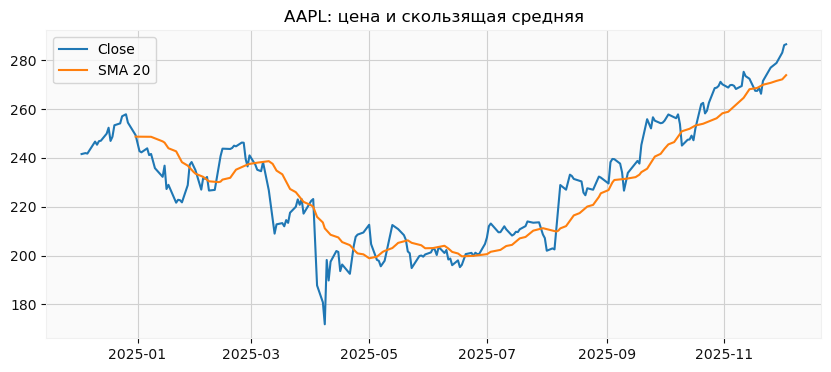

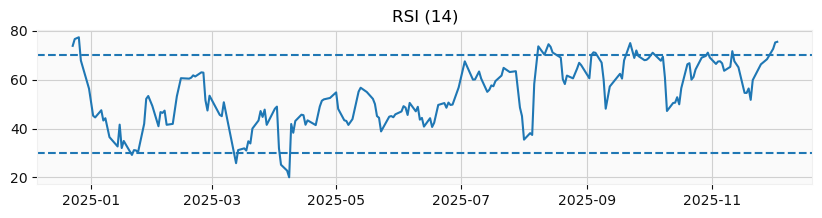

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.title(f'{ticker}: цена и скользящая средняя')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(df.index, df['RSI_14'])
plt.axhline(30, linestyle='--')
plt.axhline(70, linestyle='--')
plt.title('RSI (14)')
plt.grid(True)
plt.show()

### 3.4 Библиотека `ta`
Ещё одна популярная библиотека теханализа. Схема использования похожа.

In [ ]:
import ta as ta_lib

indicator_rsi = ta_lib.momentum.RSIIndicator(close=df[('Close', 'AAPL')], window=14)    #type: ignore
df['RSI_ta'] = indicator_rsi.rsi()
df[['RSI_14', 'RSI_ta']].tail()

Price,RSI_14,RSI_ta
Ticker,,
Date,,
2025-11-26,66.952271,66.952271
2025-11-28,68.407589,68.407589
2025-12-01,72.648182,72.648182
2025-12-02,75.249435,75.249435
2025-12-03,75.517217,75.517217


### 3.5 Библиотека `finta`
`finta` удобно работает с pandas DataFrame и поддерживает множество индикаторов.

In [30]:
from finta import TA

In [ ]:
# Для finta важны названия колонок: ['open','high','low','close','volume']
df_finta = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df_finta.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
df_finta.rename(columns={
    'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Volume': 'volume'
}, inplace=True)

In [29]:
df_finta['EMA_20'] = TA.EMA(df_finta, 20)
df_finta[['close', 'EMA_20']].tail()

,close,EMA_20
Date,,
2025-11-26,277.549988,270.088408
2025-11-28,278.850006,270.922846
2025-12-01,283.100006,272.082575
2025-12-02,286.190002,273.426140
2025-12-03,286.519989,274.673173


## 4. Резюме
- Мы загрузили финансовые данные из разных источников (междунар. рынки, MOEX, Тинькофф).
- Посмотрели базовую обработку в `pandas` и простые графики в `matplotlib`.
- Построили свечные графики в `mplfinance`.
- Добавили технические индикаторы с помощью `pandas_ta`, `ta`, `finta` и `TA-Lib`.

Дальше эти признаки можно использовать в моделях ML для задач прогнозирования или построения торговых стратегий.